In [126]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [127]:
!pip install pytorch-tabnet torch

In [128]:
!pip install catboost lightgbm pytorch-tabnet

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from pytorch_tabnet.tab_model import TabNetRegressor

# 設定資料路徑
DATA_PATH = "/content/drive/MyDrive/SideProject/用機器學習預測台灣珊瑚礁覆蓋面積/珊瑚礁/ReefCheckTaiwan_2009_2020_data.csv"
SITE_PATH = "/content/drive/MyDrive/SideProject/用機器學習預測台灣珊瑚礁覆蓋面積/珊瑚礁/ReefCheckTaiwan_2009_2020_site.csv"

In [130]:
data = pd.read_csv(DATA_PATH)
data_site = pd.read_csv(SITE_PATH)

# 選擇特徵
selected_columns = [
    'Date', 'Site', 'HC', 'SC', 'RKC', 'NIA', 'SP', 'Butterflyfish',
    'Haemulidae', 'Snapper', 'BarramundiCod', 'HumpheadWrasse',
    'BumpheadParrotfish', 'Parrotfish', 'MoralEel', 'Grouper_XS',
    'Grouper_S', 'Grouper_M', 'Grouper_L', 'Total_fish',
    'BandedCoralShrimp', 'Diadema', 'PencilUrchin', 'CollectorUrchin',
    'SeaCucumber', 'COTS', 'Triton', 'Lobster', 'GiantClam_XS',
    'GiantClam_S', 'GiantClam_M', 'GiantClam_L', 'GiantClam_XL',
    'GiantClam_XXL'
]
df = data[selected_columns].copy()

# 合併經緯度資訊
site_info = data_site[['Site', 'Latitude', 'Longitude']]
df = pd.merge(df, site_info, on='Site', how='left')

# 處理時間與缺失值
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d', errors='coerce')
df.dropna(subset=['Latitude', 'Longitude', 'Date'], inplace=True)
df['Year'] = df['Date'].dt.year

# 定義目標變數 (y = HC + SC + RKC) 並移除不必要欄位
y = df['HC'] + df['SC'] + df['RKC']
X = df.drop(columns=['HC', 'SC', 'Date', 'Site'])

# 分割與標準化
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

In [147]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"R2 : {r2:.4f}\n")
    return mae, mse, r2

def plot_results(y_true, y_pred, title):
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=range(len(y_true)), y=y_true, label='Actual', alpha=0.6)
    sns.lineplot(x=range(len(y_pred)), y=y_pred, label='Predicted', alpha=0.6)
    plt.title(title)
    plt.legend()
    plt.show()

In [132]:
from xgboost import XGBRegressor

param_grid_xgb = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 7],
    'subsample': [0.8, 0.9]
}
grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb,
                        scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test_scaled)

In [133]:
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.model_selection import GridSearchCV

param_grid_tabnet = {
    'n_d': [4, 8],
    'n_a': [4, 8],
    'n_steps': [2, 3],
    'gamma': [1.3, 1.5],
    'lambda_sparse': [1e-1, 1e-2],  # 控制特徵選擇的稀疏性
    'momentum': [0.02, 0.05],       # 控制 Batch Normalization 的穩定度
    'n_shared': [2],                # 共享層數量
    'n_independent': [2]            # 獨立層數量
}

grid_tabnet = GridSearchCV(
    TabNetRegressor(verbose=0, seed=42),
    param_grid_tabnet,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1  # 如果是 GPU 訓練，建議設為 1 避免記憶體溢出
)

# 執行 fit
grid_tabnet.fit(
    X_train_scaled.values,
    y_train.values.reshape(-1, 1),
    max_epochs=100,      # 在 fit 階段可以給予較大的 epoch
    patience=10,         # 提早停止的機制
    batch_size=128,
    virtual_batch_size=16
)

y_pred_tabnet = grid_tabnet.best_estimator_.predict(X_test_scaled.values).flatten()

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


In [134]:
from catboost import CatBoostRegressor

param_grid_cat = {
    'iterations': [200, 500],
    'learning_rate': [0.03, 0.1],
    'depth': [4, 6]
}
grid_cat = GridSearchCV(CatBoostRegressor(verbose=0, random_seed=42), param_grid_cat,
                        scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
grid_cat.fit(X_train_scaled, y_train)
y_pred_cat = grid_cat.best_estimator_.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [135]:
from lightgbm import LGBMRegressor

param_grid_lgbm = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 62]
}
grid_lgbm = GridSearchCV(LGBMRegressor(random_state=42), param_grid_lgbm,
                         scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
grid_lgbm.fit(X_train_scaled, y_train)
y_pred_lgbm = grid_lgbm.best_estimator_.predict(X_test_scaled)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000404 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 285
[LightGBM] [Info] Number of data points in the train set: 1049, number of used features: 21
[LightGBM] [Info] Start training from score 0.400381


In [148]:
evaluate_model(y_test, y_pred_tabnet, "TabNet")
evaluate_model(y_test, y_pred_xgb, "XGBoost")
evaluate_model(y_test, y_pred_cat, "CatBoost")
evaluate_model(y_test, y_pred_lgbm, "LightGBM")

--- TabNet ---
MAE: 0.1332
MSE: 0.0280
R2 : 0.3872

--- XGBoost ---
MAE: 0.1103
MSE: 0.0194
R2 : 0.5755

--- CatBoost ---
MAE: 0.1103
MSE: 0.0193
R2 : 0.5774

--- LightGBM ---
MAE: 0.1109
MSE: 0.0201
R2 : 0.5591



(0.11090835847830015, 0.020129472368212803, 0.5591054961225083)

In [149]:
# 3. Meta-Learner (Ensemble)
meta_features = pd.DataFrame({'cat': y_pred_cat, 'lgbm': y_pred_lgbm, 'xgb': y_pred_xgb, 'tabnet' : y_pred_tabnet})
meta_learner = LinearRegression().fit(meta_features, y_test)
y_pred_ensemble = meta_learner.predict(meta_features)

In [150]:
evaluate_model(y_test, y_pred_ensemble, "Meta-Learner Ensemble")

--- Meta-Learner Ensemble ---
MAE: 0.1081
MSE: 0.0186
R2 : 0.5923



(0.10814627119933917, 0.018616090159234887, 0.592253006697997)

In [139]:
# 假設你的 y_pred_ensemble 是最後的整合預測結果
# 假設你的 df_selected 是還沒 drop 'Site' 之前的完整 DataFrame

# 1. 建立結果對照表 (確保 Index 對齊)
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_ensemble
}, index=y_test.index)

# 2. 從原始資料中抓回 Site 和 Date 資訊
# 註：df_selected 是你在合併 Latitude/Longitude 後的那個 DataFrame
results_df['Site'] = data.loc[y_test.index, 'Site']
results_df['Date'] = pd.to_datetime(data.loc[y_test.index, 'Date'], format='%Y%m%d')

# 依日期排序，這樣折線圖才會按時間走
results_df = results_df.sort_values(by=['Site', 'Date'])

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_site_results(results_df, site_name):
    """
    指定地區畫出預測與實際值的對照圖
    """
    # 篩選特定地區
    site_data = results_df[results_df['Site'] == site_name]

    if site_data.empty:
        print(f"找不到地區: {site_name}，請檢查名稱是否正確。")
        return

    plt.figure(figsize=(12, 6))

    # 畫出實際值與預測值
    sns.lineplot(data=site_data, x='Date', y='Actual', label='Actual (HC+SC+RKC)', marker='o', linewidth=2)
    sns.lineplot(data=site_data, x='Date', y='Predicted', label='Predicted (Ensemble)', marker='x', linestyle='--', linewidth=2)

    plt.title(f'Prediction Performance at: {site_name}', fontsize=15)
    plt.xlabel('Survey Date', fontsize=12)
    plt.ylabel('Coral Cover (HC + SC + RKC)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 檢查一下有哪些地區可以選
print("可選地區列表:", results_df['Site'].unique())

可選地區列表: ['BeautyCave' 'BeautyRock' 'BiTou' 'ChaiKou' 'DaBaiSha' 'EasternIsletE'
 'EasternIsletS' 'EasternIsletW' 'FanCaiao' 'GongGuan' 'HeChei' 'HenRock'
 'HouShi' 'JiangJunYan' 'LionSouth' 'LongDong1.5' 'LongDong4' 'ShanYuan'
 'ShiLang' 'ShiTiPing' 'TidalPark' 'TurtleBay' 'YeLiu' 'YuChenWei']


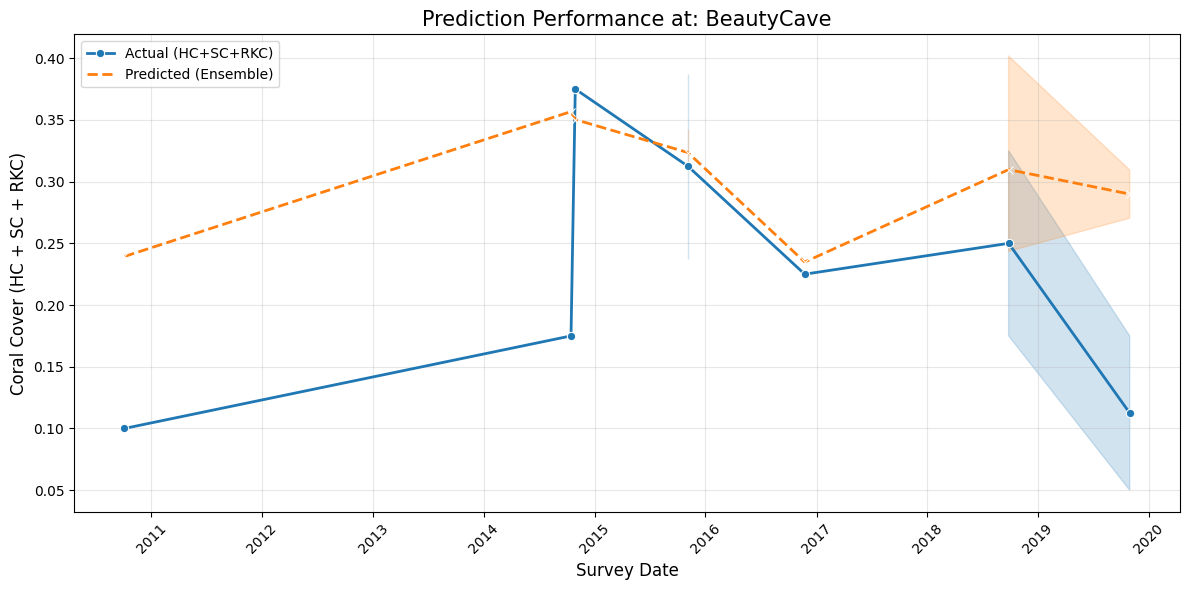

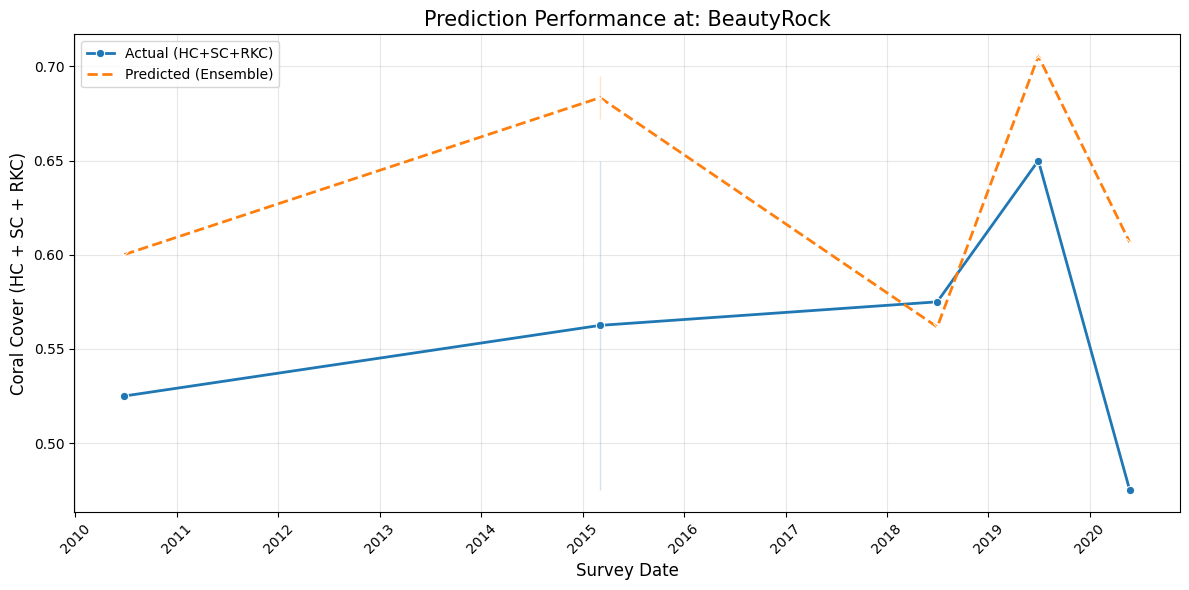

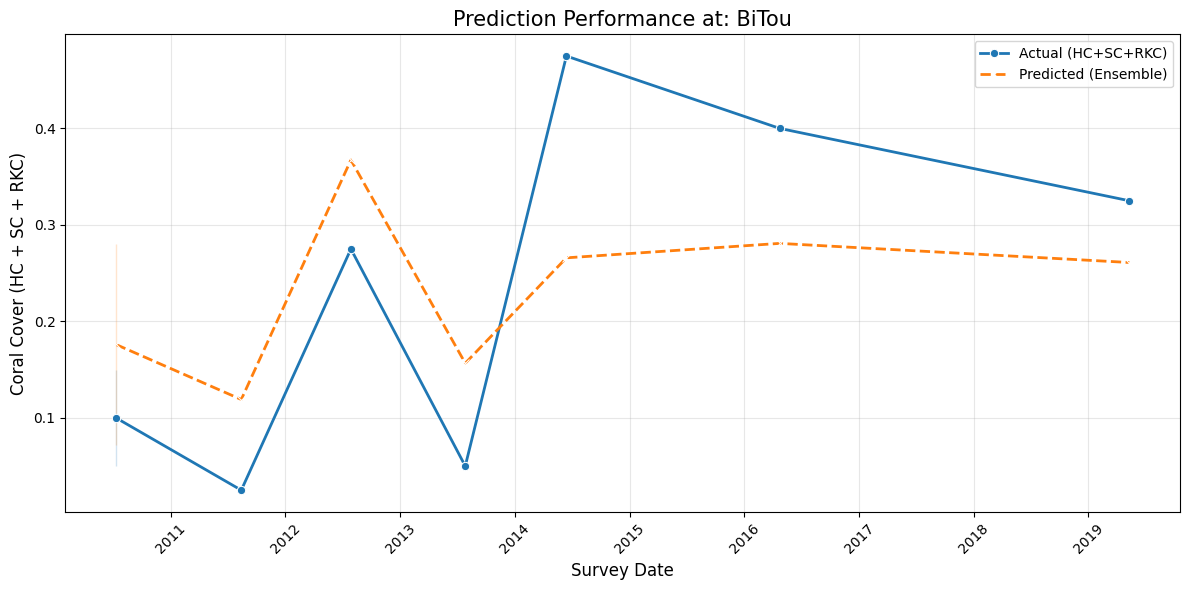

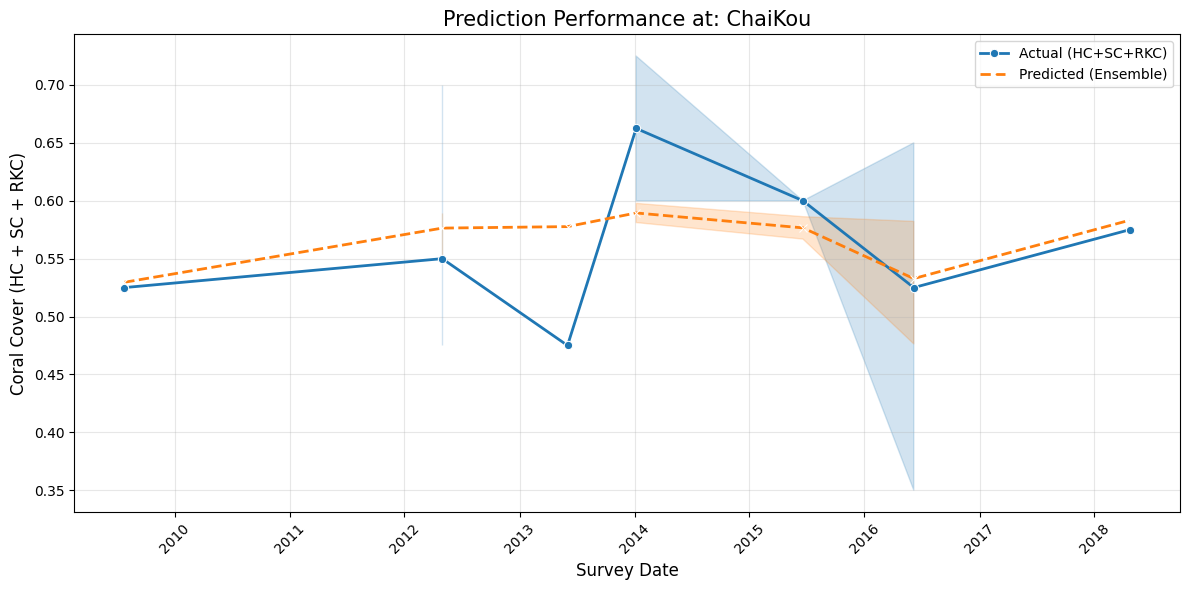

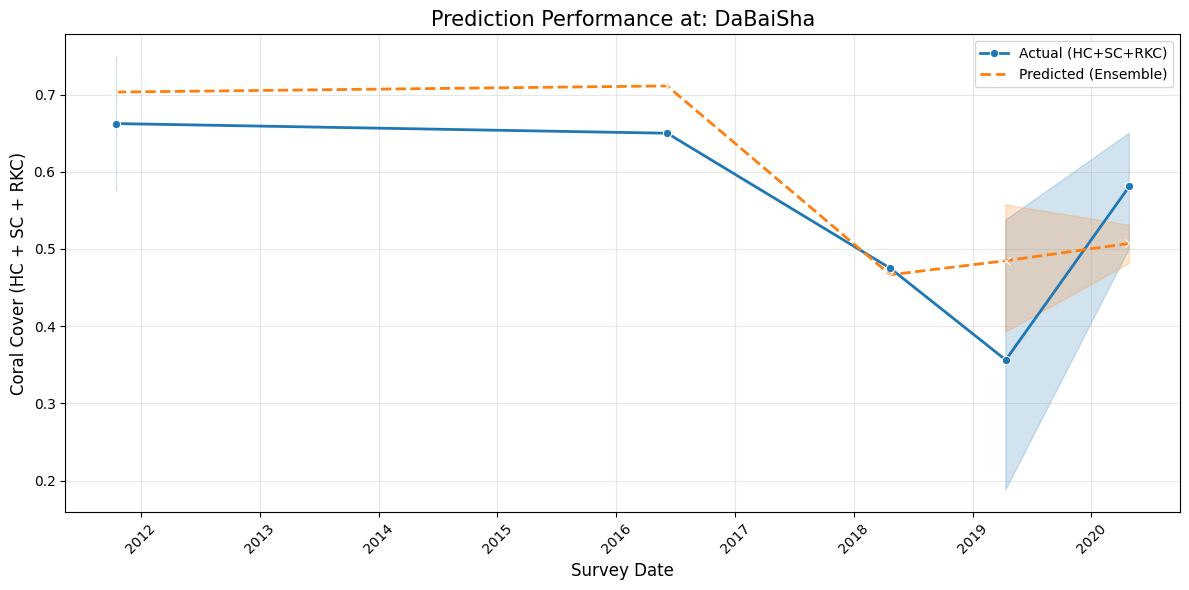

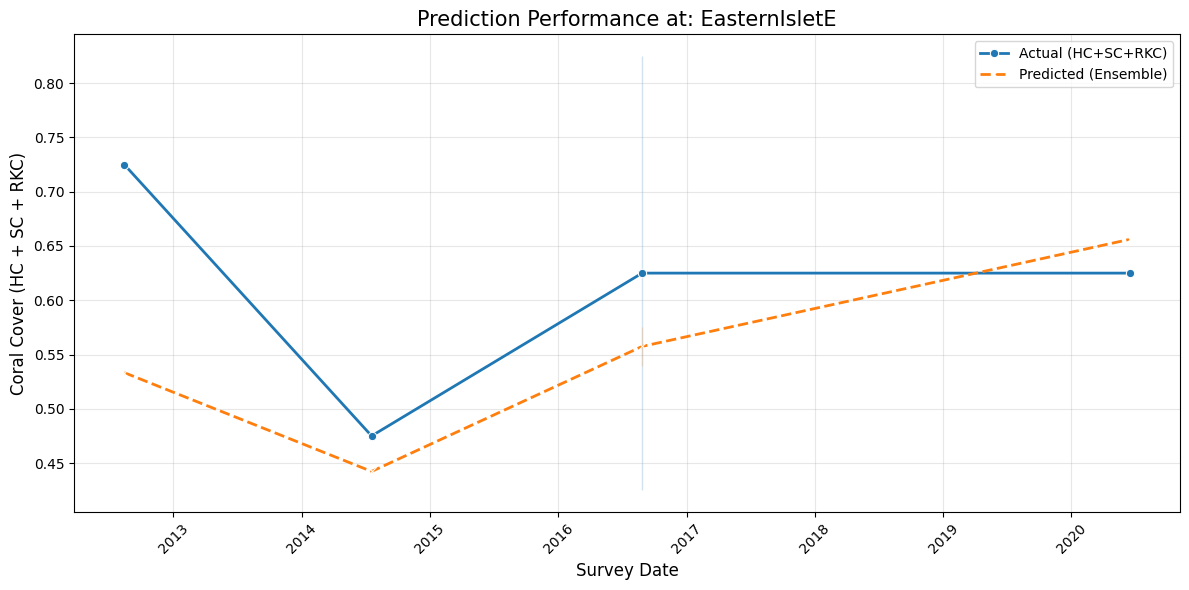

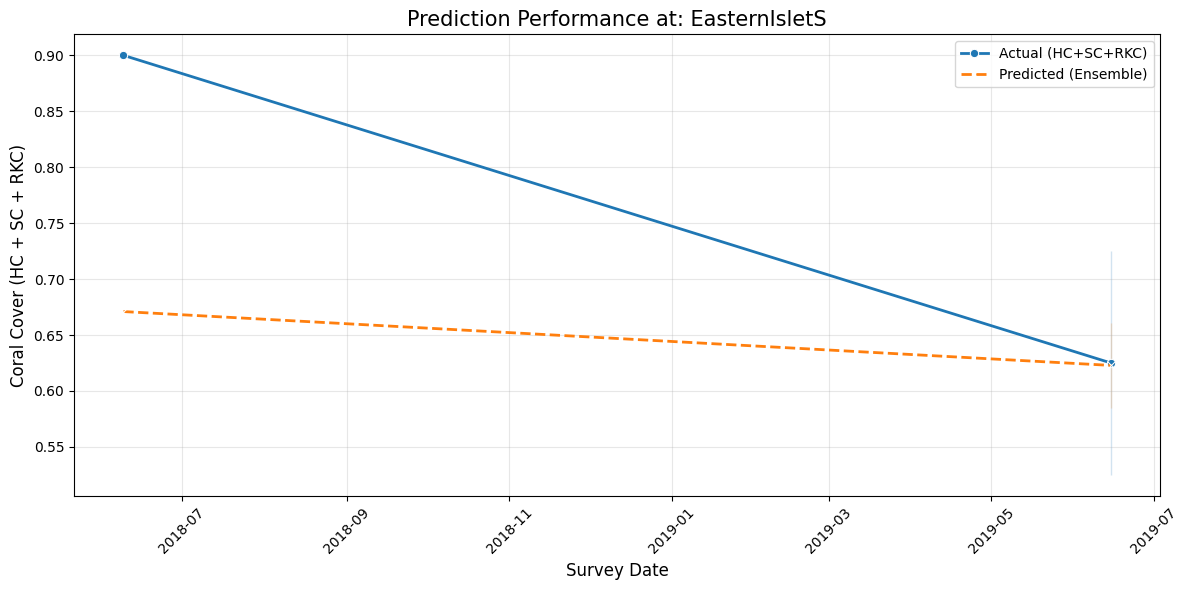

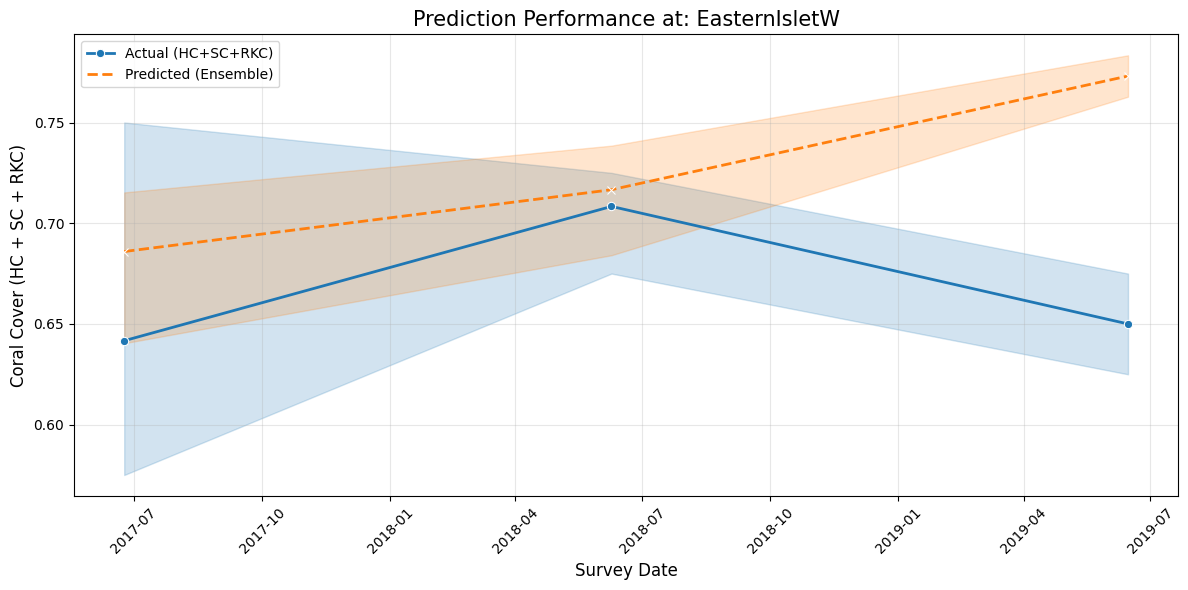

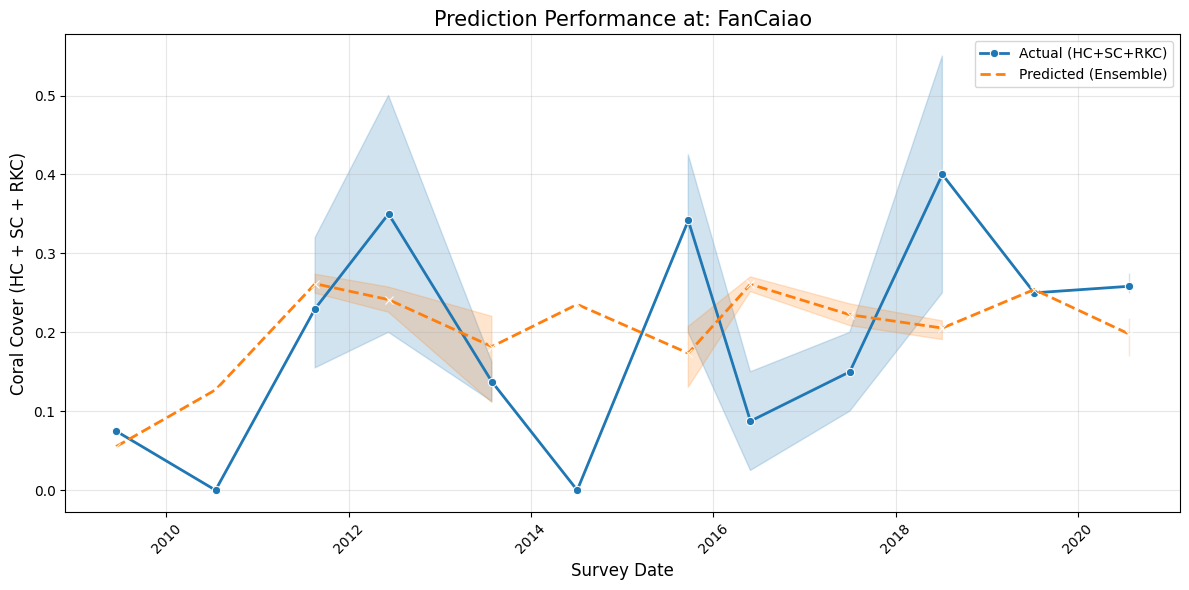

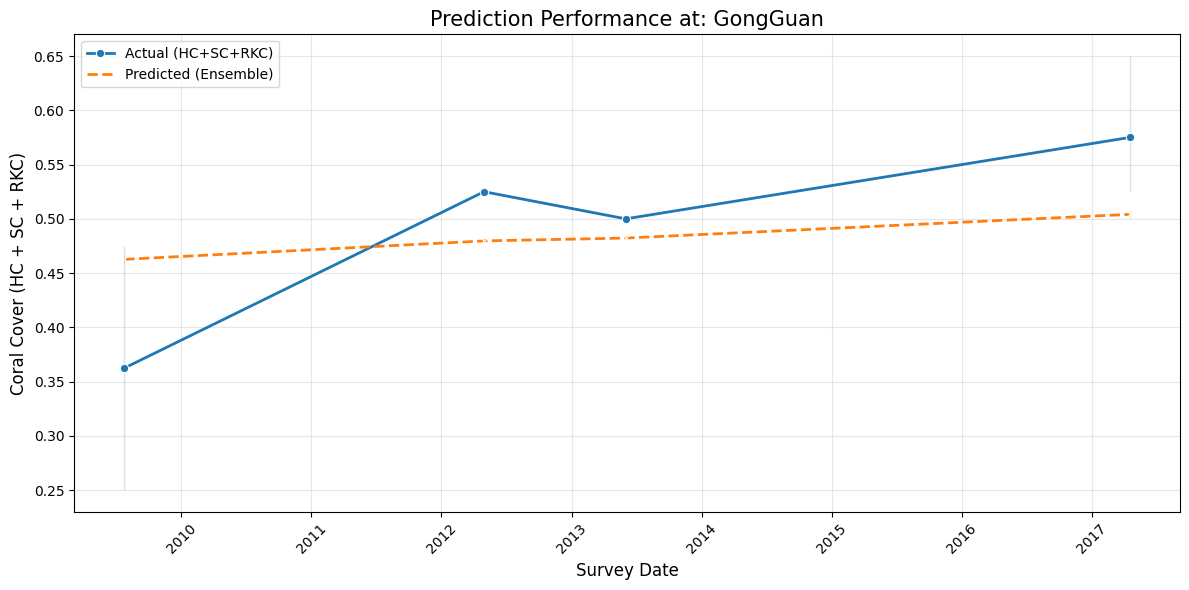

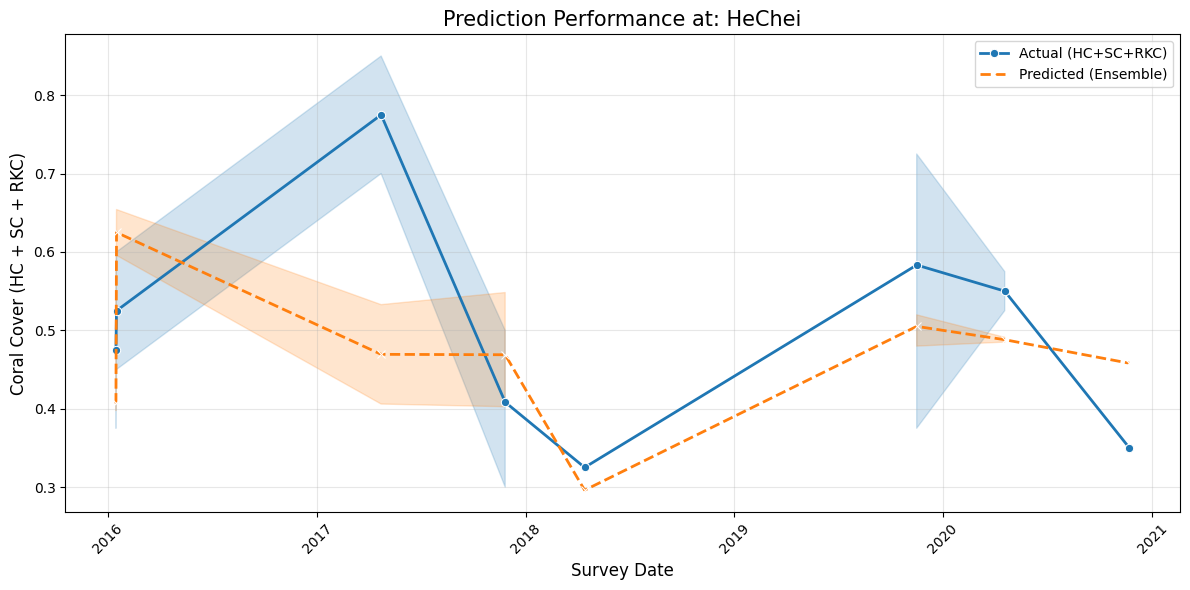

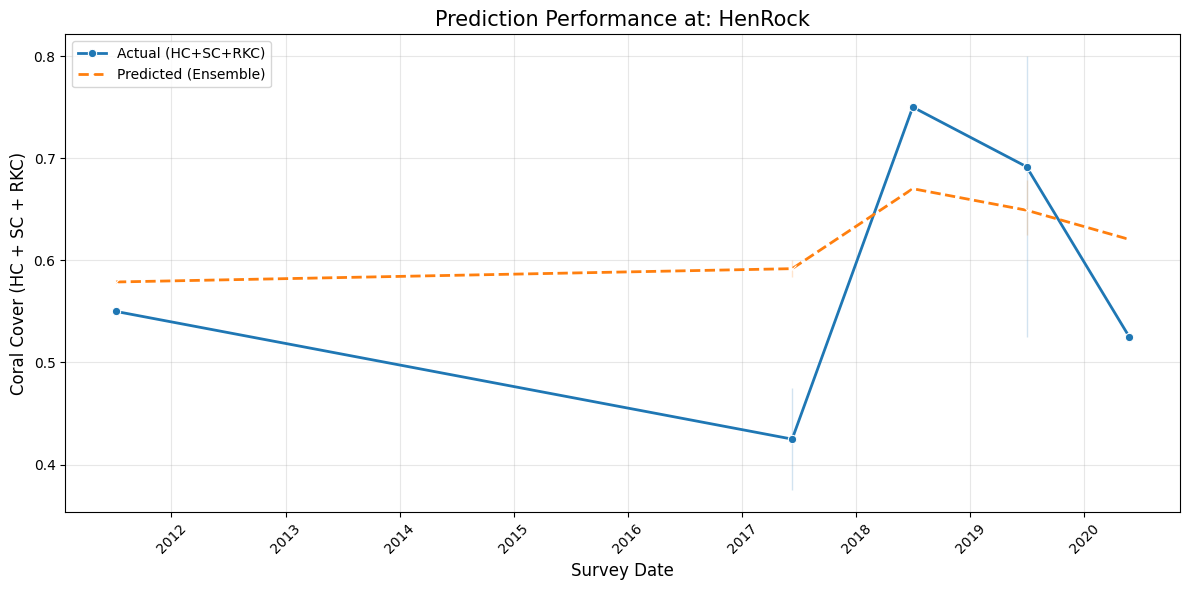

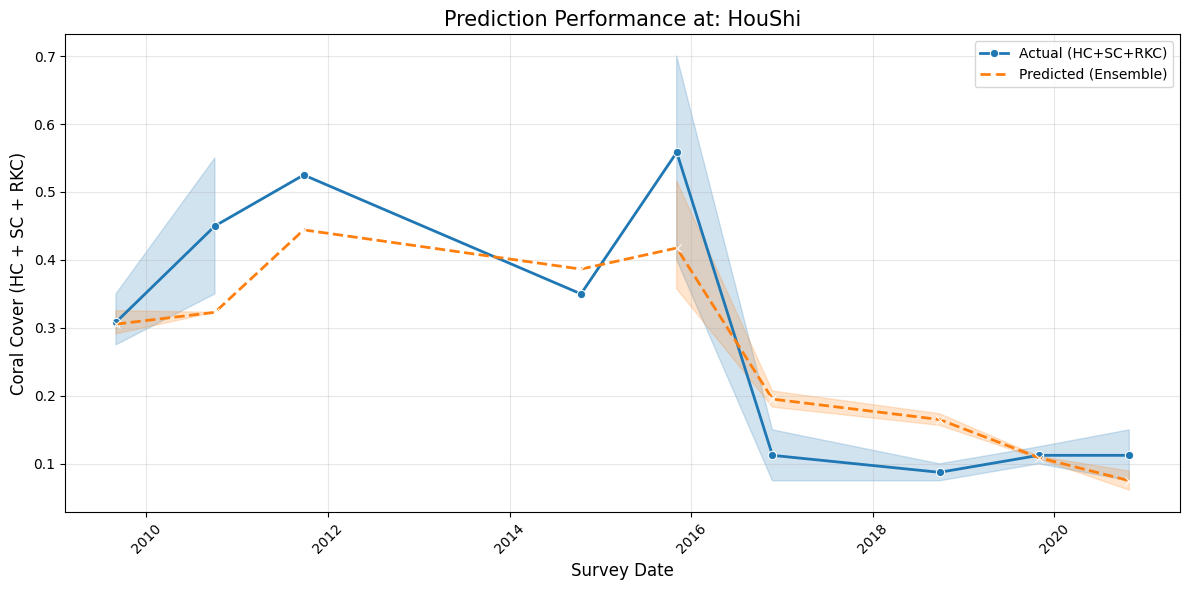

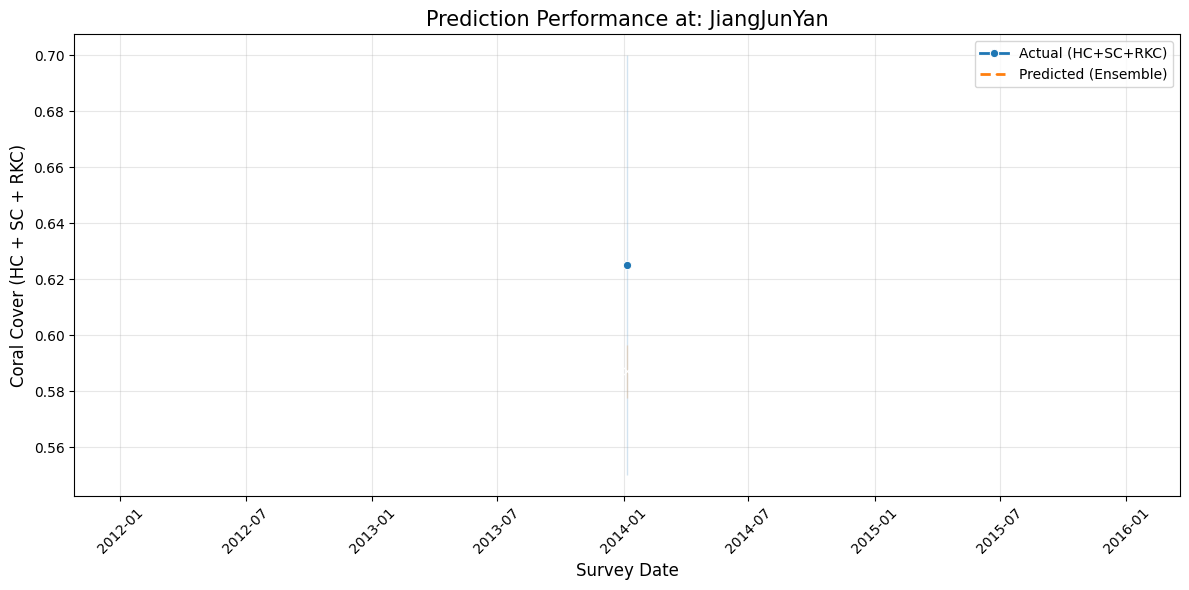

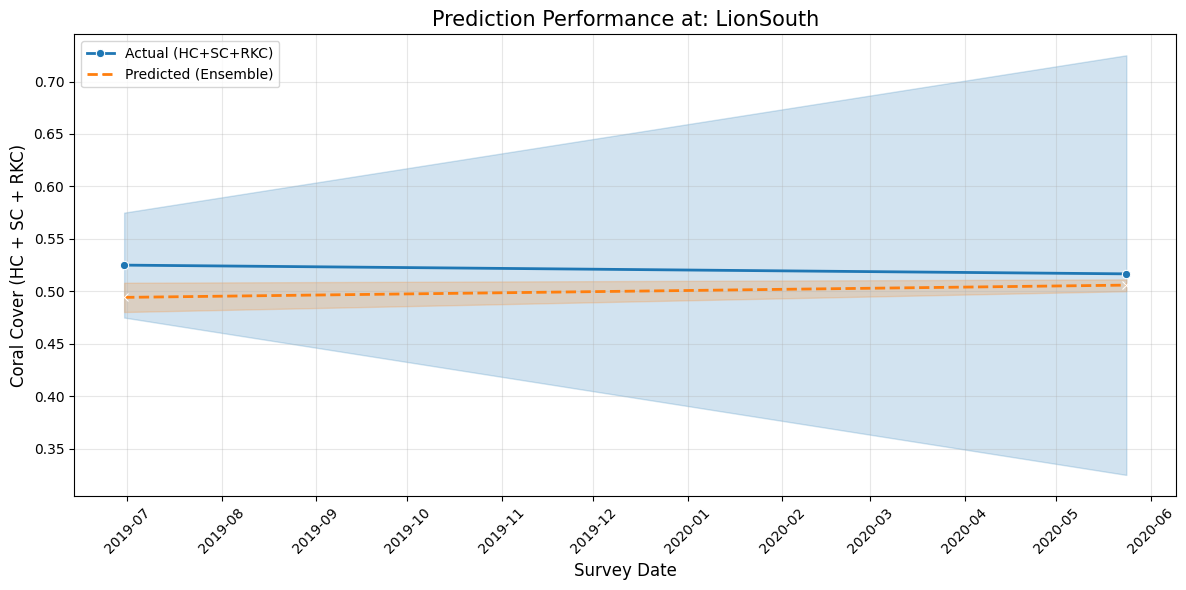

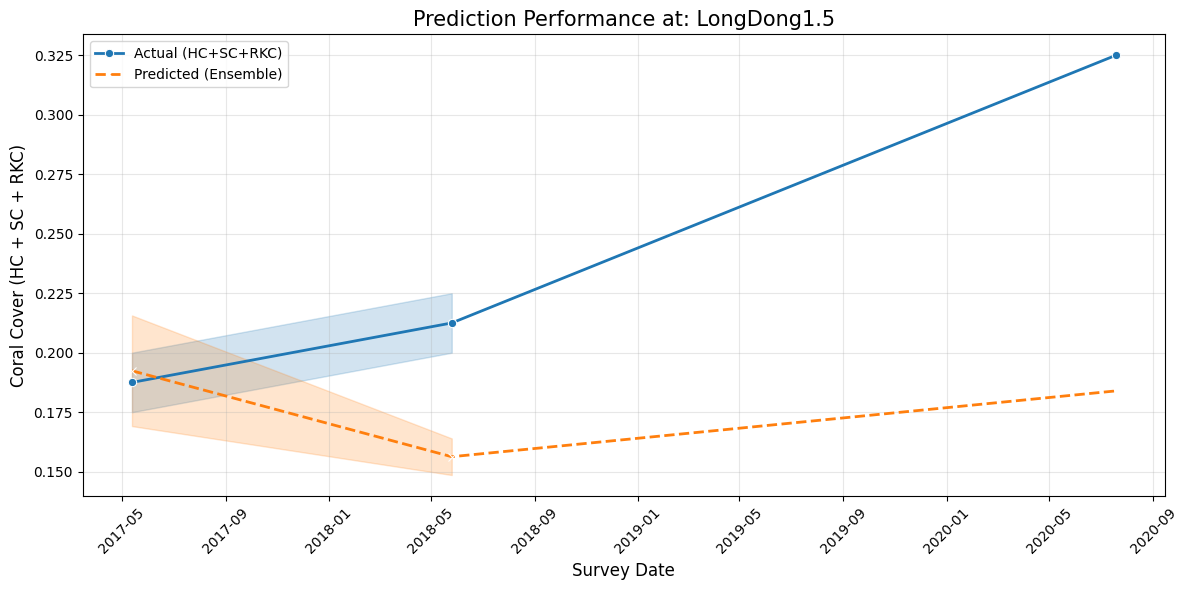

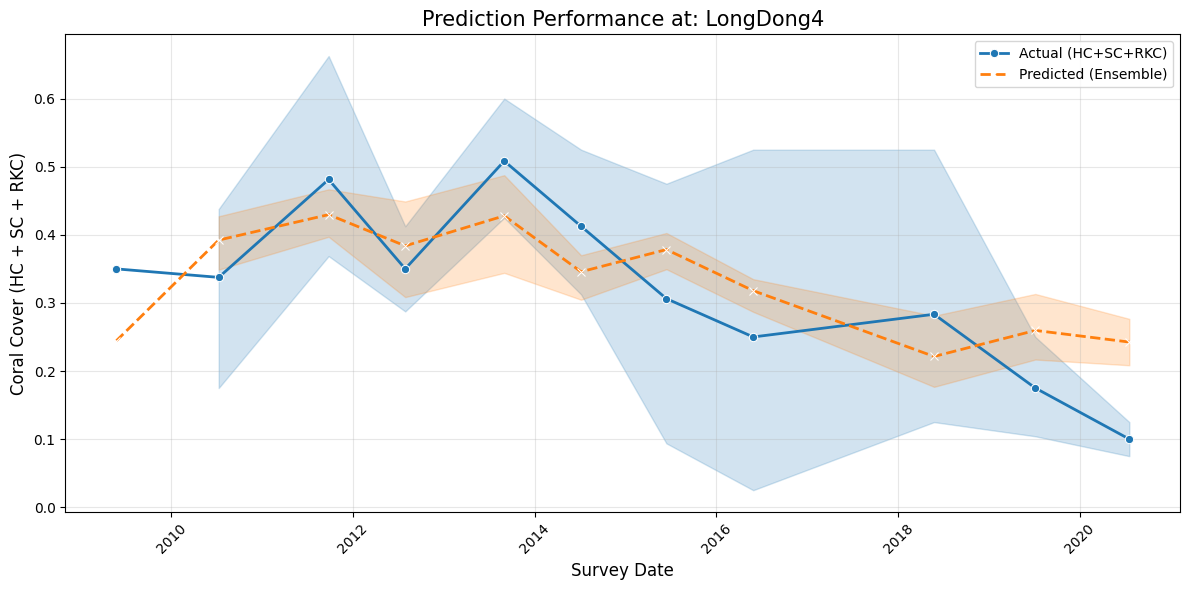

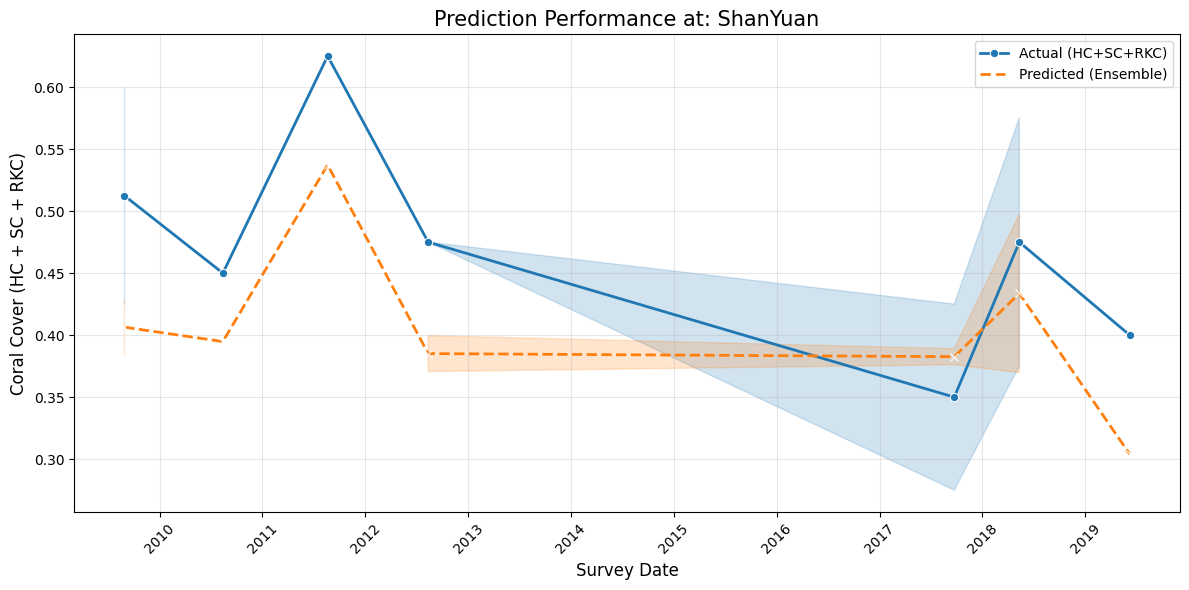

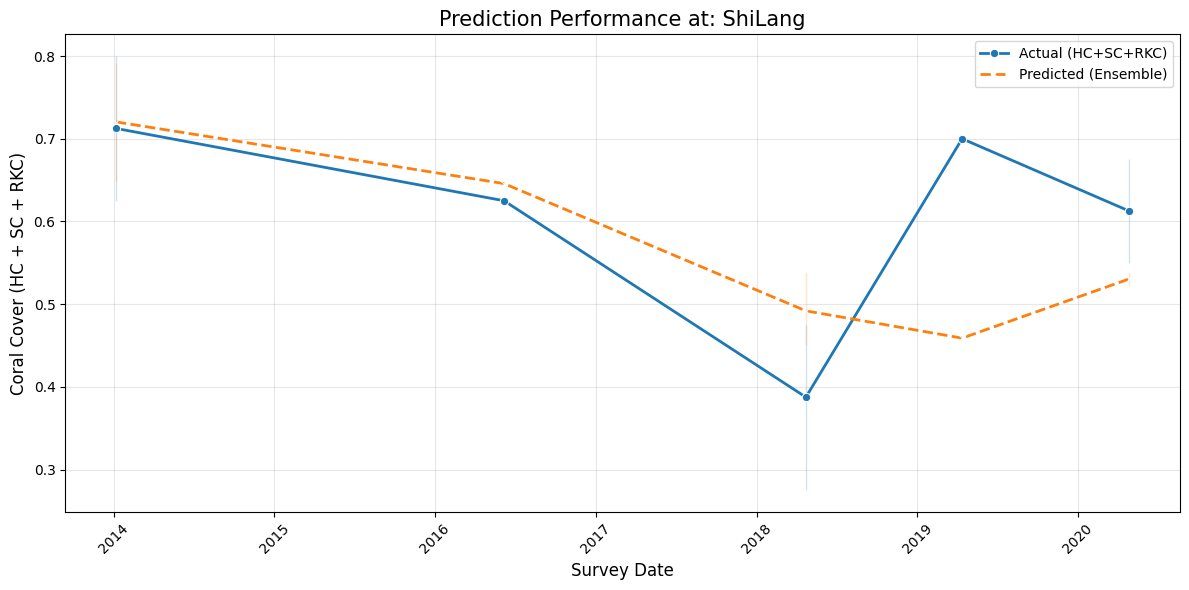

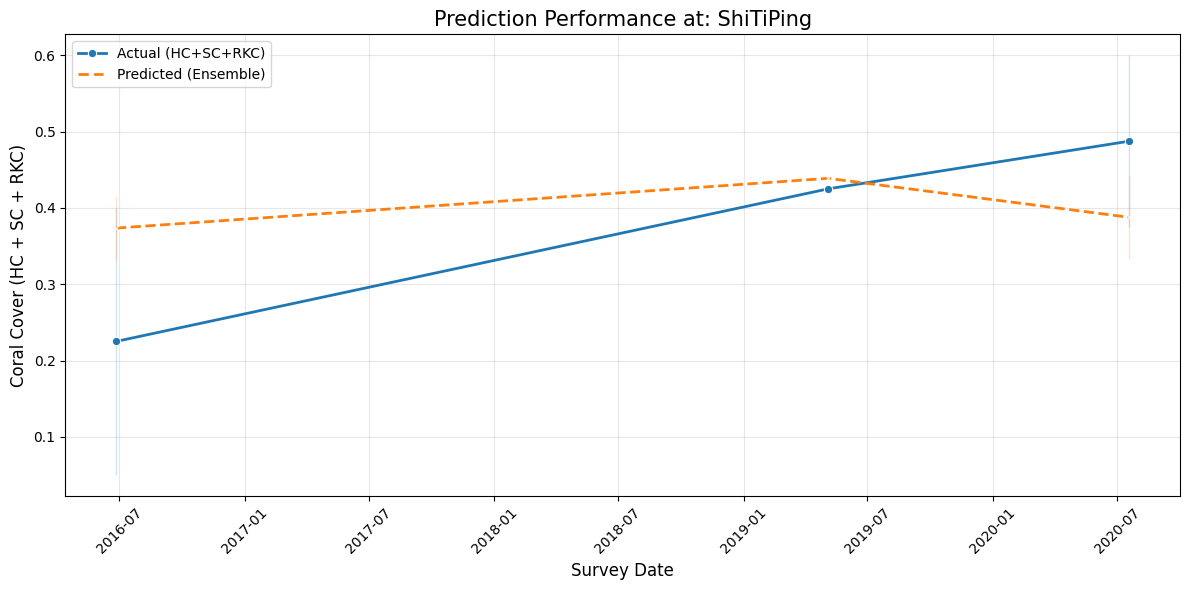

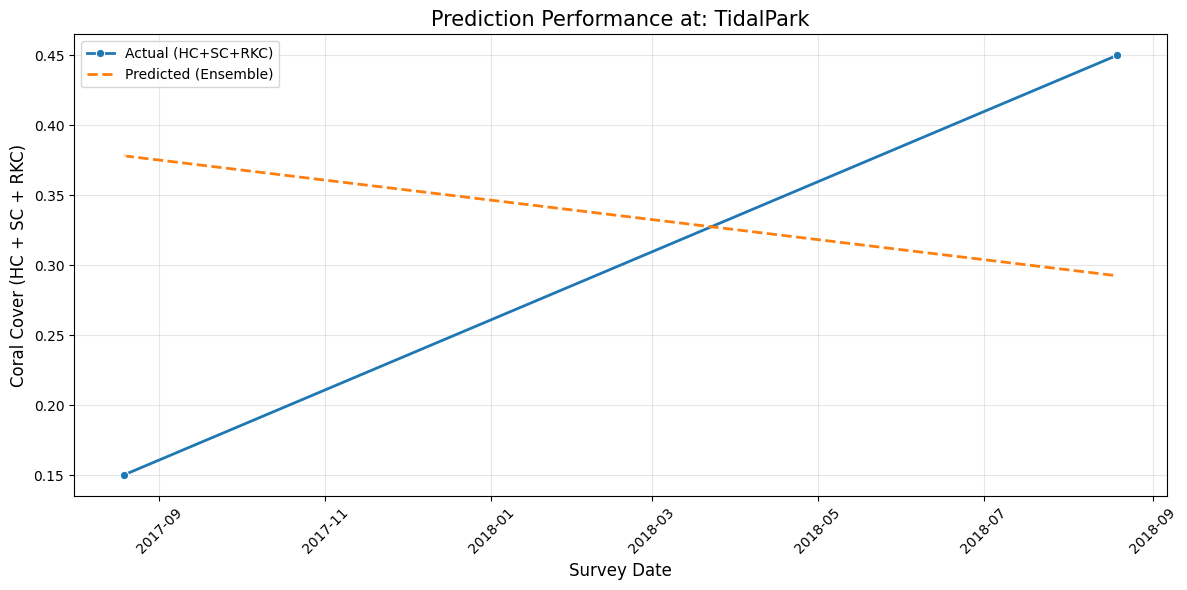

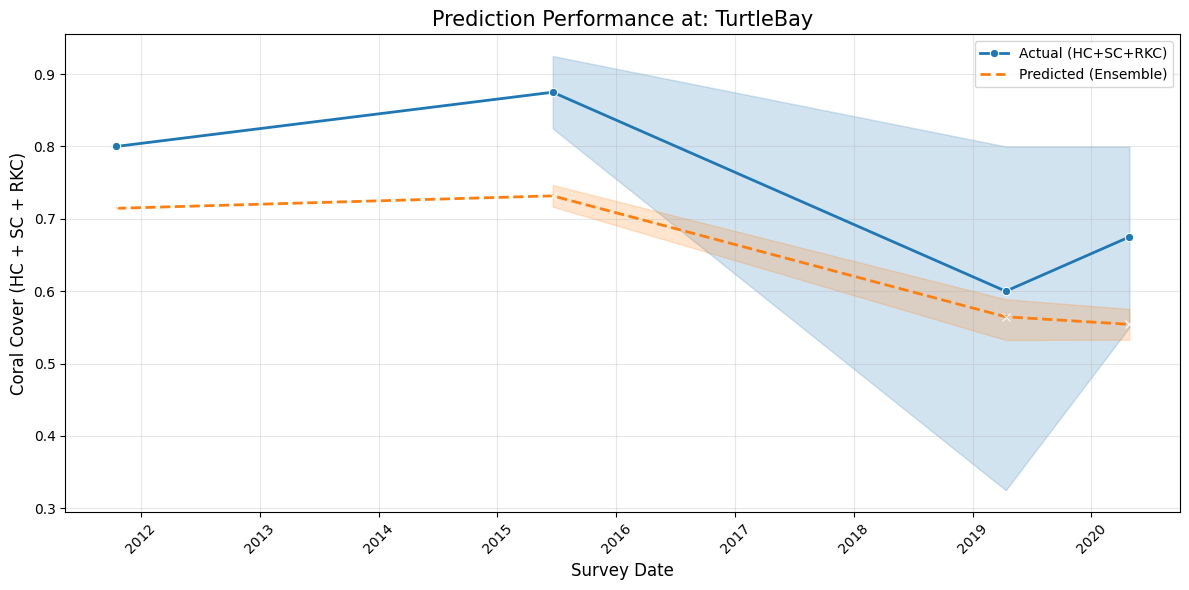

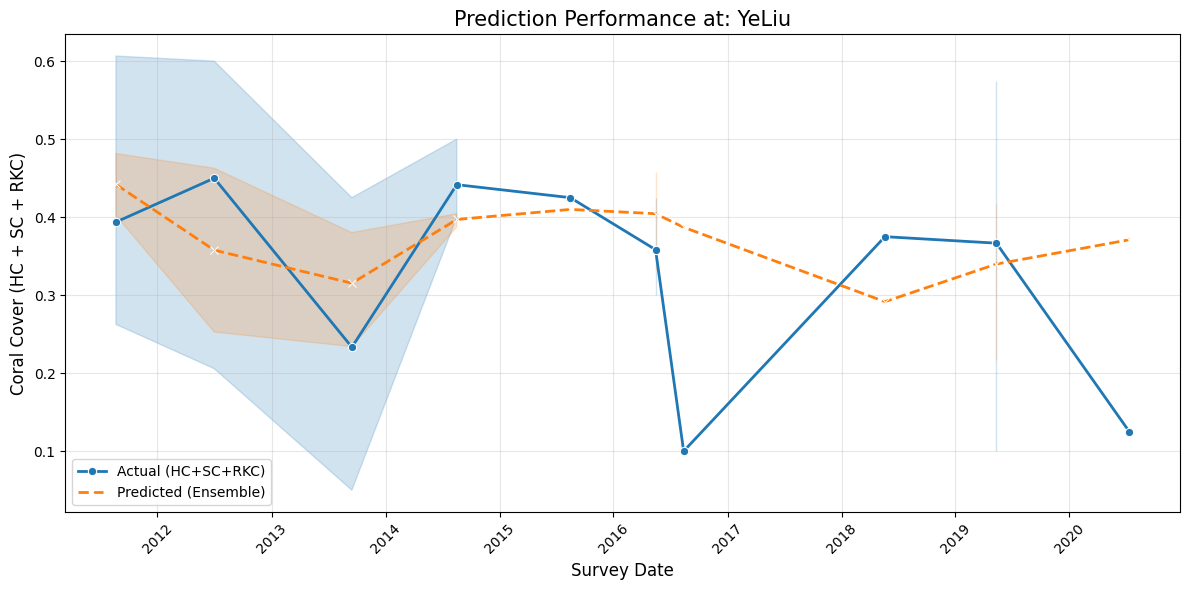

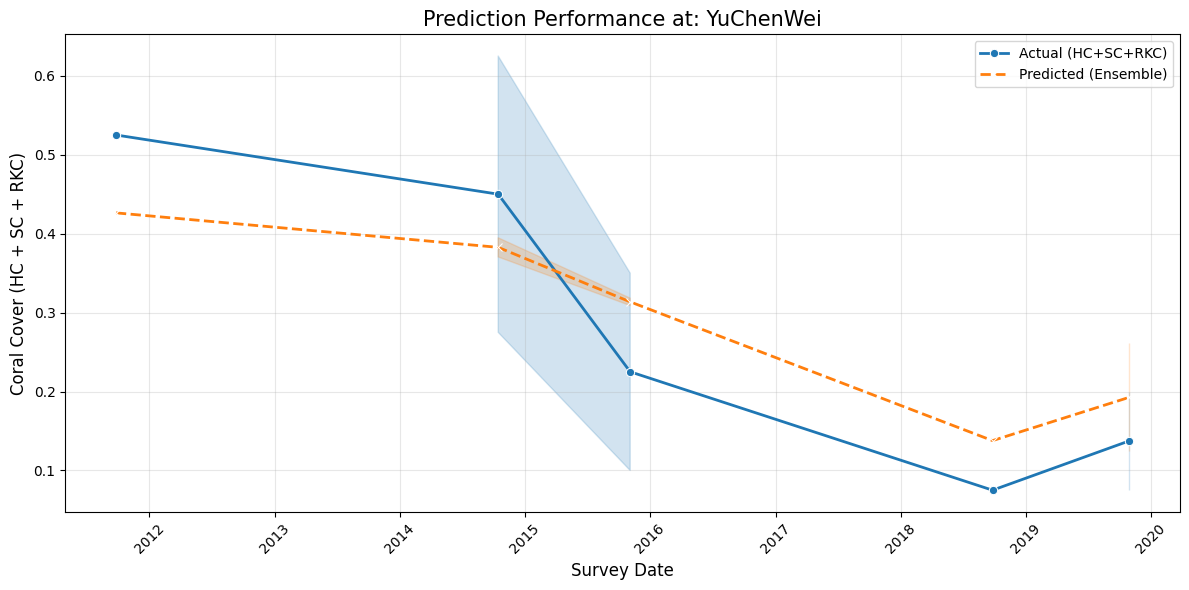

In [141]:
# 範例：查看 "綠島大香菇" 的結果 (請替換成你資料中實際有的 Site 名稱)
for i in range(len(results_df['Site'].unique())):
  target_site = results_df['Site'].unique()[i]
  plot_site_results(results_df, target_site)